Rendre les résultats sous forme: conversion_data_test_predictions_Alicia-model1.csv

In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix

)

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display


In [43]:
data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)


Set with labels (our train+test) : (284580, 6)


## EDA

In [44]:
data.head()
data.info()
data.describe(include="all")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


In [45]:
data.isnull().sum()
# pas de données manquantes

country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

In [46]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = data.sample(10000)


EDA: variable cible "converted"

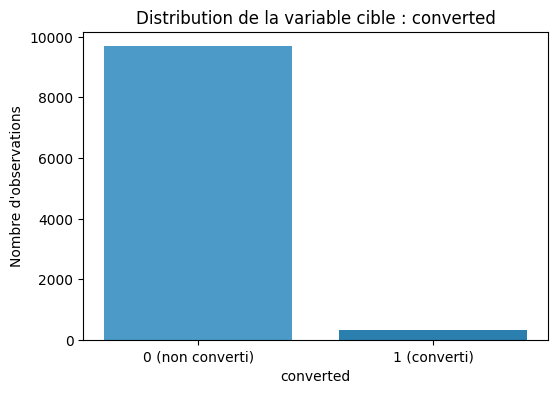

In [47]:
# Distribution de la variable cible (converted)
counts = data_sample["converted"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(
    x=counts.index,
    height=counts.values,
    color=["#4B9AC7", "#2A7FAF"]
)

plt.xticks([0, 1], ["0 (non converti)", "1 (converti)"])
plt.title("Distribution de la variable cible : converted")
plt.xlabel("converted")
plt.ylabel("Nombre d'observations")
plt.show()




EDA: variable explicative "country"

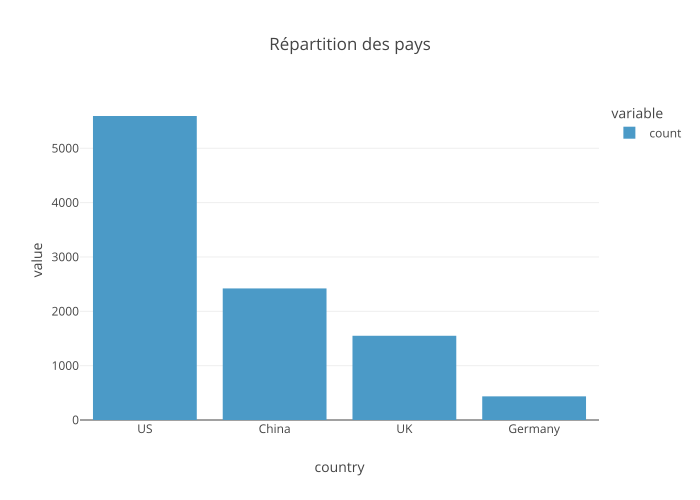

In [48]:
fig = px.bar(
    data_sample["country"].value_counts(),
    title="Répartition des pays"
)
fig.show()




EDA: variable explicative "source"

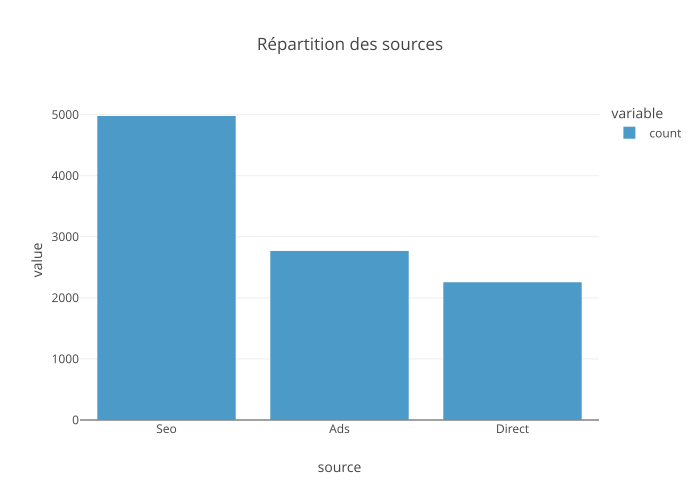

In [49]:
fig = px.bar(
    data_sample["source"].value_counts(),
    title="Répartition des sources"
)
fig.show()


EDA: variable explicative "new_user"

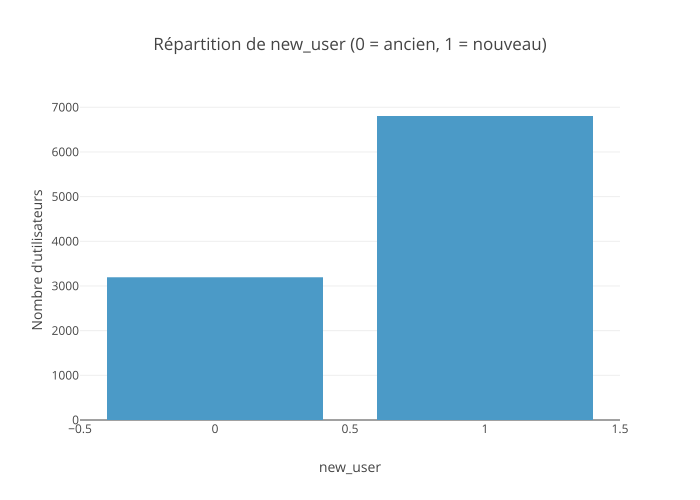

In [50]:
df_new = data_sample["new_user"].value_counts().sort_index().reset_index()
df_new.columns = ["new_user", "count"]

fig = px.bar(
    df_new,
    x="new_user",
    y="count",
    title="Répartition de new_user (0 = ancien, 1 = nouveau)",
    labels={"new_user": "new_user", "count": "Nombre d'utilisateurs"}
)

fig.show()


EDA: variable explicative "age"

In [51]:
print("Âge minimum :", data["age"].min())
print("Âge maximum :", data["age"].max())
print("Âge moyen :", round(data["age"].mean(), 2))
print("Médiane :", data["age"].median())
print("Écart-type :", round(data["age"].std(), 2))


Âge minimum : 17
Âge maximum : 123
Âge moyen : 30.56
Médiane : 30.0
Écart-type : 8.27


Le dataset contient un outlier majeur : 123 ans.

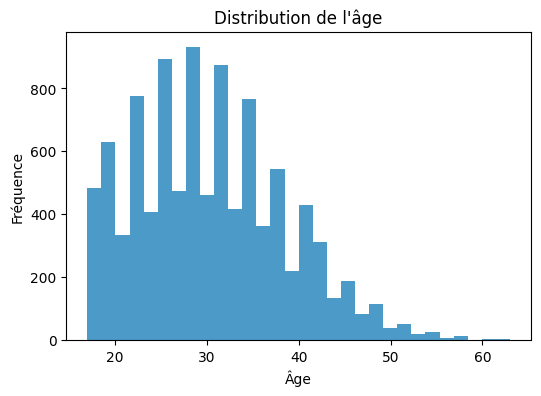

In [52]:
plt.figure(figsize=(6,4))
plt.hist(data_sample["age"], bins=30, color="#4B9AC7")
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()


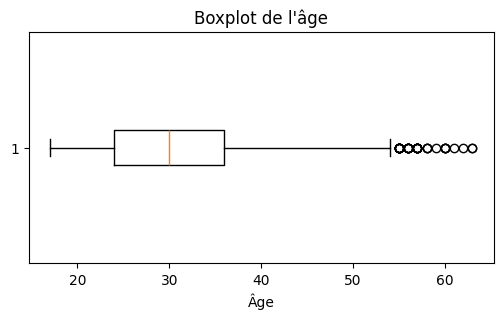

In [53]:
plt.figure(figsize=(6,3))
plt.boxplot(data_sample["age"], vert=False)
plt.title("Boxplot de l'âge")
plt.xlabel("Âge")
plt.show()

EDA: variable explicative "total_pages_visited"

In [54]:
print("Minimum :", data["total_pages_visited"].min())
print("Maximum :", data["total_pages_visited"].max())
print("Moyenne :", round(data["total_pages_visited"].mean(), 2))
print("Médiane :", data["total_pages_visited"].median())
print("Écart-type :", round(data["total_pages_visited"].std(), 2))


Minimum : 1
Maximum : 29
Moyenne : 4.87
Médiane : 4.0
Écart-type : 3.34


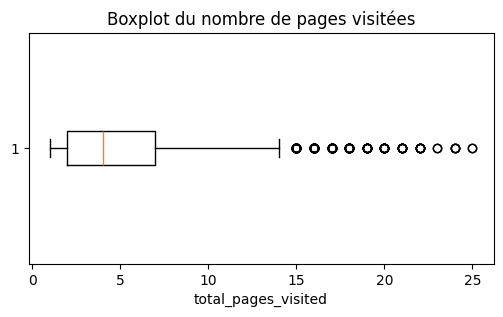

In [55]:
plt.figure(figsize=(6,3))
plt.boxplot(data_sample["total_pages_visited"], vert=False)
plt.title("Boxplot du nombre de pages visitées")
plt.xlabel("total_pages_visited")
plt.show()


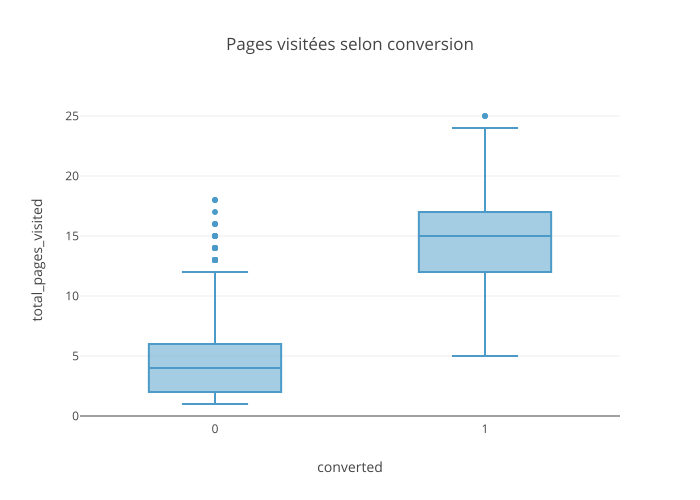

In [56]:
fig = px.box(
    data_sample,
    x="converted",
    y="total_pages_visited",
    title="Pages visitées selon conversion"
)
fig.show()


# Make your model

In [57]:
features_list = ['total_pages_visited']
numeric_indices = [0]
categorical_indices = []
target_variable = 'converted'


In [58]:
X = data.loc[:, features_list]
Y = data.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()


Explanatory variables :  Index(['total_pages_visited'], dtype='object')



In [59]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")
print()


Dividing into train and test sets...
...Done.



In [60]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

featureencoder = StandardScaler()
X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])


Encoding categorical features and standardizing numerical features...
...Done
[[-0.26070136]
 [ 0.93728655]
 [-0.85969532]
 [-0.56019834]
 [-0.26070136]]


In [61]:
# Train model
print("Train model...")
classifier = LogisticRegression() #
classifier.fit(X_train, Y_train)
print("...Done.")


Train model...
...Done.


In [62]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()


Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



In [63]:
# Use X_test, and the same preprocessings as in training pipeline,
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])


Encoding categorical features and standardizing numerical features...
...Done
[[ 0.63778957]
 [ 0.03879562]
 [-0.26070136]
 [-0.26070136]
 [ 0.63778957]]


In [64]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()


Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



In [65]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))


f1-score on train set :  0.6938517686692869
f1-score on test set :  0.7060240963855422


In [66]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()


Confusion matrix on train set : 
[[246817   1082]
 [  3280   4943]]

Confusion matrix on test set : 
[[27384   117]
 [  371   586]]



Our baseline model reaches a f1-score of almost 70%. Now, feel free to refine your model and try to beat this score ! 🚀🚀

## Train best classifier on all data and use it to make predictions on X_without_labels

In [67]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features
# used by your best classifier)
features_list = ['total_pages_visited']
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
print("Convert pandas DataFrames to arrays...")
X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels[0:5,:])


Prediction set (without labels) : (31620, 5)
Convert pandas DataFrames to arrays...
...Done
[[16]
 [ 5]
 [ 1]
 [ 6]
 [ 3]]


In [69]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = featureencoder.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])


Encoding categorical features and standardizing numerical features...
...Done
[[ 3.33326238]
 [ 0.03879562]
 [-1.15919229]
 [ 0.3382926 ]
 [-0.56019834]]


c:\Users\marzo\anaconda3\envs\jedha_base\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [70]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
data = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_EXAMPLE.csv', index=False)



## Analyzing the coefficients and interpreting the result

In this template, we just trained a model with only one feature (total_pages_visited), so there's no analysis to be done about the feature importance 🤔

Once you've included more features in your model, please take some time to analyze the model's parameters and try to find some lever for action to improve the newsletter's conversion rate

In [71]:
data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [72]:
#preprocessing

target = "converted"
X = data.drop(columns=[target], axis=1)
Y = data[target]

num_features = ["age", "total_pages_visited"]
cat_features = ["country", "source", "new_user"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y)

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ]
)


In [73]:
print("Performing preprocessings on train set...")
X_train = preprocessor.fit_transform(X_train)
print("...Done.\n")

print("Encoding labels...")
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)
print("...Done.\n")


Performing preprocessings on train set...
...Done.

Encoding labels...
...Done.



In [74]:
print("Performing preprocessings on test set...")
X_test = preprocessor.transform(X_test)
print("...Done.\n")

print("Encoding labels...")
Y_test = encoder.transform(Y_test)
print("...Done.\n")


Performing preprocessings on test set...
...Done.

Encoding labels...
...Done.



In [75]:
print("Training model...")

classifier = LogisticRegression(class_weight="balanced")
classifier.fit(X_train, Y_train)

print("...Done.\n")


Training model...


...Done.



In [76]:
Y_test_pred = classifier.predict(X_test)

print("accuracy :", accuracy_score(Y_test, Y_test_pred))
print("f1-score :", f1_score(Y_test, Y_test_pred))


accuracy : 0.9413170286035561
f1-score : 0.5079552150854449


## Ameliorer le f1 score

In [77]:
# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0, stratify=Y
)

# SAUVEGARDE DES DONNÉES BRUTES POUR GRIDSEARCHCV
X_train_raw = X_train.copy()
Y_train_raw = Y_train.copy()

X_test_raw = X_test.copy()
Y_test_raw = Y_test.copy()


In [78]:
# GridSearch 

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_raw, Y_train_raw)

print("Best parameters :", grid.best_params_)
print("Best f1-score (CV) :", grid.best_score_)



NameError: name 'pipeline' is not defined

In [ ]:
# utiliser le meilleur modèle

best_model = grid.best_estimator_

Y_test_pred = best_model.predict(X_test_raw)

from sklearn.metrics import f1_score, accuracy_score

print("Accuracy :", accuracy_score(Y_test_raw, Y_test_pred))
print("F1-score :", f1_score(Y_test_raw, Y_test_pred))


Accuracy : 0.9413170286035561
F1-score : 0.5079552150854449


## Random forest classifier (améliorons le score)

In [79]:
# Pipeline RandomForest
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=0))
])


In [80]:
# grid Search

param_grid_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_raw, Y_train_raw)

print("Best parameters :", rf_grid.best_params_)
print("Best f1-score (CV) :", rf_grid.best_score_)



Best parameters : {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best f1-score (CV) : 0.5885754887545639


In [81]:
best_rf = rf_grid.best_estimator_

Y_test_pred_rf = best_rf.predict(X_test_raw)

print("Accuracy :", accuracy_score(Y_test_raw, Y_test_pred_rf))
print("F1-score :", f1_score(Y_test_raw, Y_test_pred_rf))


Accuracy : 0.9596774193548387
F1-score : 0.5782025362984745


## Ada boost (améliorons le f1 score)

In [82]:
from sklearn.ensemble import AdaBoostClassifier

ada_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", AdaBoostClassifier(random_state=0))
])


In [83]:
param_grid_ada = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.5, 1.0, 1.5]
}

ada_grid = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=param_grid_ada,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

ada_grid.fit(X_train_raw, Y_train_raw)

print("Best parameters :", ada_grid.best_params_)
print("Best f1-score (CV) :", ada_grid.best_score_)


Best parameters : {'clf__learning_rate': 1.5, 'clf__n_estimators': 200}
Best f1-score (CV) : 0.7600040786995285


In [84]:
best_ada = ada_grid.best_estimator_

Y_test_pred_ada = best_ada.predict(X_test_raw)

print("Accuracy :", accuracy_score(Y_test_raw, Y_test_pred_ada))
print("F1-score :", f1_score(Y_test_raw, Y_test_pred_ada))


Accuracy : 0.9852765478951437
F1-score : 0.7468277945619335


In [89]:
# soumission

# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
#data = {
#    'converted': classifier.predict(X_without_labels)
#}

#Y_predictions = pd.DataFrame(columns=['converted'],data=data)
#Y_predictions.to_csv('conversion_data_test_predictions_EXAMPLE.csv', index=False)





data_test = pd.read_csv("conversion_data_test.csv")
Y_test_pred_final = best_ada.predict(data_test)
submission = pd.DataFrame({
    "converted": Y_test_pred_final
})
submission.to_csv("conversion_data_test_predictions_Alicia-model1.csv", index=False)


## XGboost (améliorons encore f1 score)

In [91]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=0
    ))
])


In [92]:
param_grid_xgb = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train_raw, Y_train_raw)

print("Best parameters :", xgb_grid.best_params_)
print("Best f1-score (CV) :", xgb_grid.best_score_)


c:\Users\marzo\anaconda3\envs\jedha_base\Lib\site-packages\xgboost\training.py:199: UserWarning:

[14:42:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




Best parameters : {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best f1-score (CV) : 0.7668643411293813


In [93]:
best_xgb = xgb_grid.best_estimator_

Y_test_pred_xgb = best_xgb.predict(X_test_raw)

print("Accuracy :", accuracy_score(Y_test_raw, Y_test_pred_xgb))
print("F1-score :", f1_score(Y_test_raw, Y_test_pred_xgb))


Accuracy : 0.9853819664066343
F1-score : 0.7510472770795931


In [94]:
# soumission

data_test = pd.read_csv("conversion_data_test.csv")
Y_test_pred_final = best_xgb.predict(data_test)
submission = pd.DataFrame({
    "converted": Y_test_pred_final
})
submission.to_csv("conversion_data_test_predictions_Alicia-model2.csv", index=False)

## Threshold optimisation

In [95]:
probas = best_xgb.predict_proba(X_test_raw)[:, 1]


In [96]:

thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
    preds = (probas > t).astype(int)
    scores.append(f1_score(Y_test_raw, preds))

best_t = thresholds[np.argmax(scores)]
best_f1 = max(scores)

print("Best threshold :", best_t)
print("Best F1-score :", best_f1)


Best threshold : 0.33999999999999986
Best F1-score : 0.7605555555555555
